In [1]:
# Install KaggleHub package
!pip install -q kagglehub

In [2]:
import kagglehub

# Download the Amazon Alexa Reviews dataset
dataset_path = kagglehub.dataset_download("sid321axn/amazon-alexa-reviews")

print("Dataset downloaded successfully.")
print("Location:", dataset_path)

100%|██████████| 164k/164k [00:00<00:00, 388kB/s]

Extracting files...
Dataset downloaded successfully.
Location: /root/.cache/kagglehub/datasets/sid321axn/amazon-alexa-reviews/versions/3


In [3]:
import pandas as pd
import os

In [7]:
os.listdir(dataset_path)

['amazon_alexa.tsv']

In [8]:
df = pd.read_csv(dataset_path + "/amazon_alexa.tsv", sep="\t")

In [9]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [10]:
df.shape

(3150, 5)

In [11]:
df.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [12]:
df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [13]:
df = df[["verified_reviews"]]

In [14]:
df = df.dropna()

In [15]:
df.head()

,verified_reviews
0,Love my Echo!
1,Loved it!
2,"Sometimes while playing a game, you can answer..."
3,I have had a lot of fun with this thing. My 4 ...
4,Music


In [22]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = word_tokenize(text)

    filtered_words = []

    for word in words:
        if word not in stop_words:
            filtered_words.append(word)

    return " ".join(filtered_words)

df["Clean_Review"] = df["verified_reviews"].apply(clean_text)

In [25]:
from textblob import TextBlob

def check_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"
df["Sentiment"] = df["Clean_Review"].apply(check_sentiment)

df.head()

,verified_reviews,Clean_Review,Sentiment
0,Love my Echo!,love echo,Positive
1,Loved it!,loved,Positive
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...,Negative
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing 4 yr old learns dinosaurs contro...,Positive
4,Music,music,Neutral


In [26]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Positive    2526
Neutral      447
Negative     176
Name: count, dtype: int64


In [28]:
negative_reviews = df[df["Sentiment"] == "Negative"]
print("Negative Customer Reviews")
for review in negative_reviews["verified_reviews"].head(10):
    print(review)

Negative Customer Reviews
Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home.
Just what I expected....
Does everything as expected and more.
The outlet does not work with it. Was disappointed in that.
it's annoying that everything they show Alexa as being able to do has to be downloaded. You spend so  much time trying to figure out how to phrase it for the machine that you may as well just look it up yourself
It performs pretty much as expected, but I am very disappointed it will not provide me with the terminology I need to play various kinds of music without subscribing to the Amazon music service.  I understand my music choices may be limited, but without knowing HOW TO ASK, I cannot access the music that is provided free along with my Echo purchase.  Do you have a chart showing the language I need to use?
Sad joke. Worthless.
Really disappo

In [29]:
positive = len(df[df["Sentiment"] == "Positive"])
negative = len(df[df["Sentiment"] == "Negative"])
neutral = len(df[df["Sentiment"] == "Neutral"])

In [30]:
print("Business Insights")
print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
print("Neutral Reviews  :", neutral)

print("\nSuggestions")

if negative > 0:
    print("- Improve voice recognition.")
    print("- Improve product quality.")
    print("- Improve connectivity.")
    print("- Improve customer support.")
else:
    print("- Customers are highly satisfied.")

Business Insights
Positive Reviews : 2526
Negative Reviews : 176
Neutral Reviews  : 447

Suggestions
- Improve voice recognition.
- Improve product quality.
- Improve connectivity.
- Improve customer support.


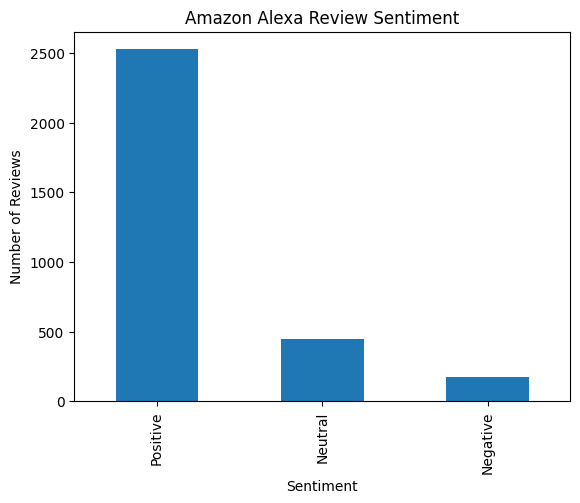

In [31]:
import matplotlib.pyplot as plt

sentiment_count.plot(kind="bar")

plt.title("Amazon Alexa Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()